# Phase 4 — Feature Engineering

Objectif : transformer le dataset brut `encounters.csv` en un dataset **prêt pour le modèle**.

Les features brutes (moyennes de groupe, CR moyen, XP brut...) capturent des valeurs absolues.
Le modèle apprendra mieux à partir de features qui expriment des **relations** entre le groupe et les monstres.

Étapes :
1. **Charger** le dataset et vérifier sa qualité.
2. **Explorer** les distributions et corrélations des features brutes.
3. **Créer** les features dérivées (ratios, écarts, transformations).
4. **Encoder** le label `difficulty` en variable ordinale.
5. **Séparer** les données en train/test (avant tout preprocessing).
6. **Sauvegarder** en `data/processed/encounters_features.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

RAW       = Path.cwd().parent / "data" / "raw"
PROCESSED = Path.cwd().parent / "data" / "processed"
PROCESSED.mkdir(exist_ok=True)

df = pd.read_csv(RAW / "encounters.csv")

print("Shape :", df.shape)
print("Valeurs manquantes :", df.isnull().sum().sum())
print()
print("Distribution des labels :")
print(df["difficulty"].value_counts().reindex(["Easy", "Medium", "Hard", "Deadly"]))
print()
df.head()

Shape : (4000, 19)
Valeurs manquantes : 0

Distribution des labels :
difficulty
Easy      1000
Medium    1000
Hard      1000
Deadly    1000
Name: count, dtype: int64



,party_size,party_avg_level,party_avg_hp,party_avg_ac,party_avg_str,party_avg_dex,party_avg_con,monster_count,monster_avg_cr,monster_avg_hp,monster_avg_ac,xp_raw,xp_adjusted,xp_ratio,threshold_easy,threshold_medium,threshold_hard,threshold_deadly,difficulty
0,4,16.00,162.5,19.0,12.0,18.2,17.0,1,6.0,130.0,16.0,2300,2300,0.075,6850,13500,20400,30500,Easy
1,3,8.33,76.3,15.0,12.7,17.3,14.3,1,3.0,78.0,15.0,700,700,0.106,1450,2900,4400,6600,Easy
2,6,11.67,120.0,16.8,16.5,15.8,15.3,1,8.0,142.0,10.0,3900,3900,0.157,5450,10900,16600,24800,Easy
3,6,19.33,195.8,15.0,12.8,16.7,16.7,2,7.5,109.0,15.5,7300,10950,0.155,15600,31700,47300,70700,Easy
4,3,14.67,148.3,16.7,15.3,16.3,16.3,1,6.0,133.0,15.0,2300,2300,0.124,4100,8200,12400,18600,Easy


## 2. Exploration des features brutes

Avant de créer de nouvelles features, on explore ce qu'on a déjà.

Deux questions clés :
- **Distributions** : certaines features sont-elles très asymétriques (skewed) ? Si oui, une transformation `log1p` sera nécessaire pour ne pas écraser les petites valeurs.
- **Corrélations avec le label** : quelles features brutes sont déjà discriminantes ? Cela guidera les features dérivées à construire à l'étape suivante.

> On encode temporairement `difficulty` en ordinal (Easy=0, Medium=1, Hard=2, Deadly=3) uniquement pour calculer les corrélations — ce n'est pas encore l'encodage final.

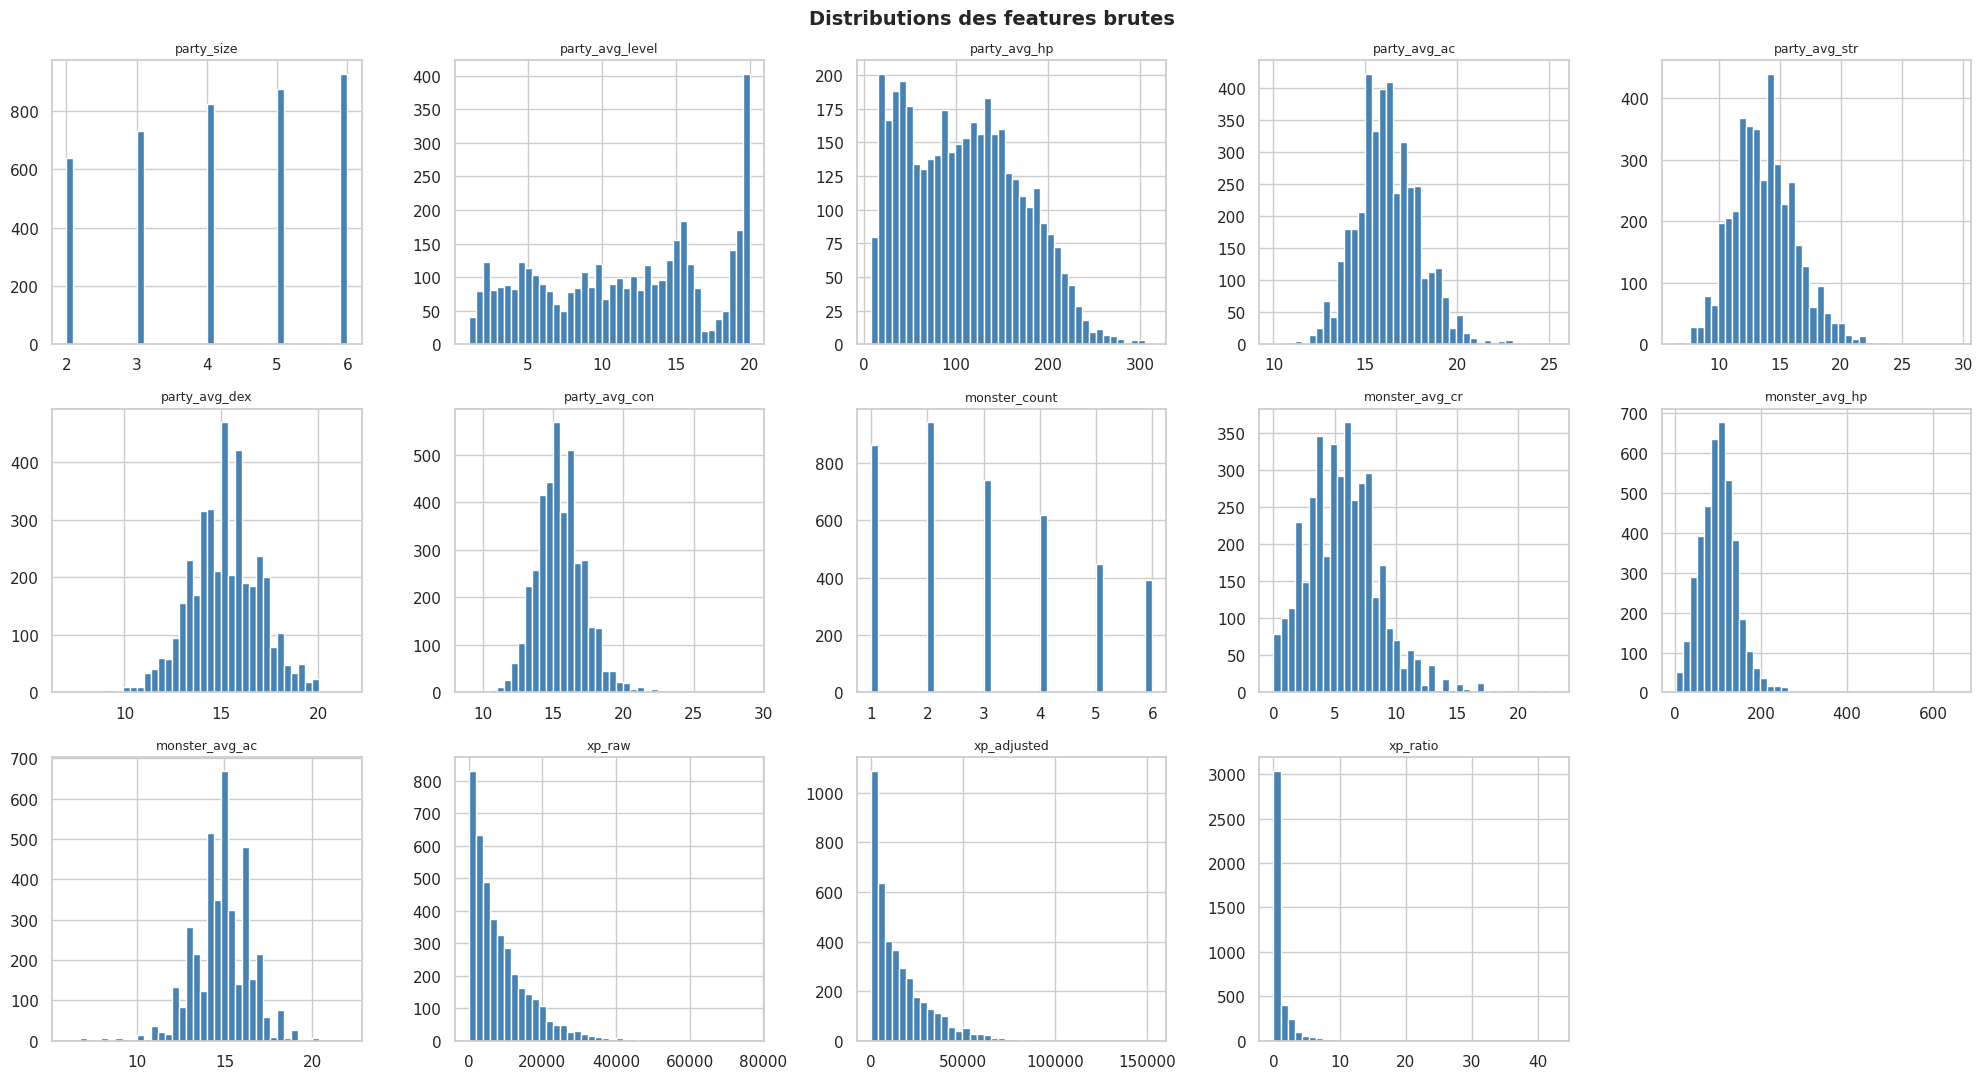

In [2]:
DIFFICULTY_ORDER = {"Easy": 0, "Medium": 1, "Hard": 2, "Deadly": 3}
df["difficulty_num"] = df["difficulty"].map(DIFFICULTY_ORDER)

FEATURES = [
    "party_size", "party_avg_level", "party_avg_hp", "party_avg_ac",
    "party_avg_str", "party_avg_dex", "party_avg_con",
    "monster_count", "monster_avg_cr", "monster_avg_hp", "monster_avg_ac",
    "xp_raw", "xp_adjusted", "xp_ratio",
]

# --- Distributions ---
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
fig.suptitle("Distributions des features brutes", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, FEATURES):
    ax.hist(df[col], bins=40, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes.flat[len(FEATURES):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

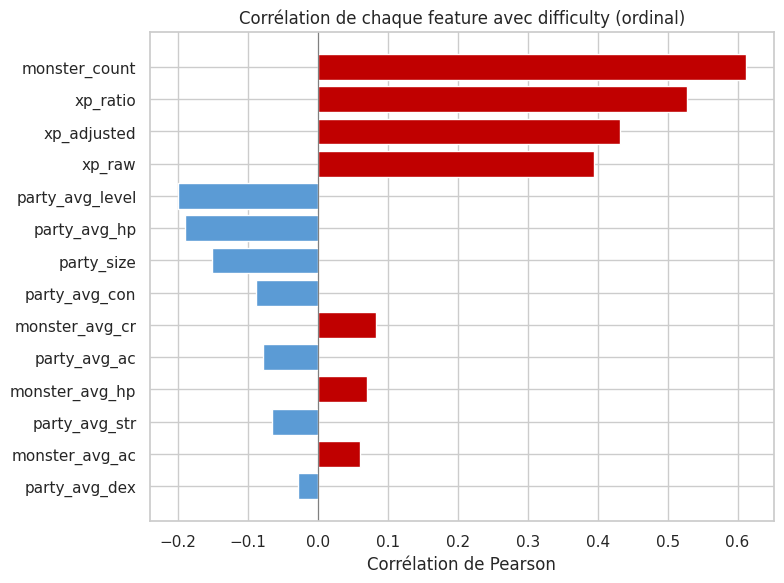

Corrélations triées par valeur absolue :
monster_count      0.612
xp_ratio           0.528
xp_adjusted        0.432
xp_raw             0.394
party_avg_level   -0.200
party_avg_hp      -0.190
party_size        -0.151
party_avg_con     -0.089
monster_avg_cr     0.083
party_avg_ac      -0.078
monster_avg_hp     0.071
party_avg_str     -0.065
monster_avg_ac     0.060
party_avg_dex     -0.028


In [3]:
# --- Corrélations avec le label ---
corr_with_label = (
    df[FEATURES + ["difficulty_num"]]
    .corr()["difficulty_num"]
    .drop("difficulty_num")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c00000" if v > 0 else "#5b9bd5" for v in corr_with_label]
ax.barh(corr_with_label.index[::-1], corr_with_label.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Corrélation de chaque feature avec difficulty (ordinal)", fontsize=12)
ax.set_xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

print("Corrélations triées par valeur absolue :")
print(corr_with_label.round(3).to_string())

> **⚠️ Note sur `party_avg_level`**
>
> Cette feature présente une corrélation avec la difficulté qui est en partie un **artefact du générateur** : on tire les monstres dans la plage `[avg_level/4 − 1, avg_level + 3]`, donc les groupes de haut niveau affrontent mécaniquement des monstres de CR plus élevé. Le modèle pourrait apprendre cette corrélation sans comprendre la vraie logique D&D.
>
> La feature `xp_ratio` (XP ajusté / seuil Mortel) **neutralise cet effet** en normalisant le XP par rapport à la puissance du groupe — elle est indépendante du niveau absolu. Si `party_avg_level` s'avère trop influent en Phase 5, on l'écartera.

## 3. Création des features dérivées

Les features brutes mesurent des valeurs absolues. On crée des features qui capturent des **relations** entre le groupe et les monstres — c'est ce qui a du sens pour prédire la difficulté.

### Features dérivées créées

| Feature | Formule | Ce qu'elle mesure |
|---|---|---|
| `cr_level_delta` | `monster_avg_cr − party_avg_level` | À quel point les monstres surpassent le niveau du groupe (positif = monstres plus forts) |
| `hp_ratio` | `monster_avg_hp / party_avg_hp` | Endurance relative des monstres par rapport au groupe |
| `ac_gap` | `monster_avg_ac − party_avg_ac` | Écart de défense (positif = monstres plus durs à toucher) |

### Transformations log1p

`xp_raw`, `xp_adjusted` et `monster_avg_hp` sont fortement asymétriques (queue à droite).
La transformation `log1p(x) = log(1 + x)` compresse les grandes valeurs sans écraser les petites.

### Colonnes supprimées

- `threshold_easy/medium/hard/deadly` : ce sont les valeurs exactes utilisées pour calculer le label → **fuite de données** (le modèle pourrait reconstruire la réponse directement).
- `xp_raw`, `xp_adjusted`, `monster_avg_hp`, `party_avg_hp` : remplacées par leurs versions `log1p`.

In [4]:
df_feat = df.copy()

# --- Features dérivées ---
df_feat["cr_level_delta"] = df_feat["monster_avg_cr"] - df_feat["party_avg_level"]
df_feat["hp_ratio"]       = df_feat["monster_avg_hp"] / df_feat["party_avg_hp"]
df_feat["ac_gap"]         = df_feat["monster_avg_ac"] - df_feat["party_avg_ac"]

# --- Transformations log1p ---
df_feat["log_xp_raw"]        = np.log1p(df_feat["xp_raw"])
df_feat["log_xp_adjusted"]   = np.log1p(df_feat["xp_adjusted"])
df_feat["log_monster_avg_hp"] = np.log1p(df_feat["monster_avg_hp"])
df_feat["log_party_avg_hp"]  = np.log1p(df_feat["party_avg_hp"])

# --- Suppression des colonnes redondantes ou avec fuite de données ---
DROP_COLS = [
    "threshold_easy", "threshold_medium", "threshold_hard", "threshold_deadly",
    "xp_raw", "xp_adjusted", "monster_avg_hp", "party_avg_hp",
    "difficulty_num",
]
df_feat = df_feat.drop(columns=DROP_COLS)

print("Features finales :", df_feat.shape[1], "colonnes")
print()
print(df_feat.dtypes.to_string())
print()
df_feat.describe().round(2)

Features finales : 18 colonnes

party_size              int64
party_avg_level       float64
party_avg_ac          float64
party_avg_str         float64
party_avg_dex         float64
party_avg_con         float64
monster_count           int64
monster_avg_cr        float64
monster_avg_ac        float64
xp_ratio              float64
difficulty                str
cr_level_delta        float64
hp_ratio              float64
ac_gap                float64
log_xp_raw            float64
log_xp_adjusted       float64
log_monster_avg_hp    float64
log_party_avg_hp      float64



,party_size,party_avg_level,party_avg_ac,party_avg_str,party_avg_dex,party_avg_con,monster_count,monster_avg_cr,monster_avg_ac,xp_ratio,cr_level_delta,hp_ratio,ac_gap,log_xp_raw,log_xp_adjusted,log_monster_avg_hp,log_party_avg_hp
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,4.18,11.47,16.23,13.74,15.19,15.40,3.01,5.72,14.79,1.23,-5.75,1.23,-1.44,8.48,8.95,4.53,4.48
std,1.39,5.78,1.74,2.58,1.81,1.71,1.61,3.04,1.64,2.07,4.34,0.81,2.15,1.26,1.42,0.50,0.72
min,2.00,1.00,10.00,6.50,7.00,9.00,1.00,0.00,6.00,0.00,-16.00,0.07,-10.90,2.40,2.40,1.10,2.14
25%,3.00,6.17,15.00,12.00,14.00,14.30,2.00,3.58,14.00,0.43,-9.11,0.73,-2.80,7.74,8.12,4.30,3.99
50%,4.00,11.82,16.00,13.50,15.20,15.30,3.00,5.50,15.00,0.67,-5.50,0.98,-1.40,8.68,9.23,4.62,4.67
75%,5.00,16.00,17.30,15.30,16.40,16.40,4.00,7.50,16.00,1.00,-2.14,1.46,0.00,9.38,10.01,4.85,5.04
max,6.00,20.00,25.30,29.50,21.50,29.00,6.00,23.00,22.00,42.50,3.00,8.13,8.00,11.24,11.94,6.49,5.75


## 4. Encodage du label `difficulty`

Le label `difficulty` est une chaîne de caractères ("Easy", "Medium", etc.). Le modèle a besoin d'un entier.

### Pourquoi un encodage ordinal et pas one-hot ?

Il existe deux façons d'encoder une variable catégorielle :

- **One-hot** : crée une colonne binaire par classe (`is_easy`, `is_medium`, `is_hard`, `is_deadly`). Utile quand les catégories sont **sans ordre** (ex : couleurs, races D&D).
- **Ordinal** : assigne un entier croissant selon un ordre naturel. Utile quand les catégories ont un **ordre logique**.

Ici, la difficulté a un ordre clair : Easy < Medium < Hard < Deadly. Un encodage ordinal préserve cette information et simplifie l'évaluation (la confusion entre Easy et Medium est moins grave qu'entre Easy et Deadly).

| Label | Valeur |
|---|---|
| Easy | 0 |
| Medium | 1 |
| Hard | 2 |
| Deadly | 3 |

In [5]:
DIFFICULTY_ORDER = {"Easy": 0, "Medium": 1, "Hard": 2, "Deadly": 3}

df_feat["difficulty_encoded"] = df_feat["difficulty"].map(DIFFICULTY_ORDER)

# Vérification : aucune valeur manquante, distribution attendue
print("Valeurs manquantes dans difficulty_encoded :", df_feat["difficulty_encoded"].isnull().sum())
print()
print("Distribution :")
print(
    df_feat.groupby("difficulty")["difficulty_encoded"]
    .first()
    .reindex(["Easy", "Medium", "Hard", "Deadly"])
    .to_string()
)
print()
print(df_feat["difficulty_encoded"].value_counts().sort_index().to_string())

Valeurs manquantes dans difficulty_encoded : 0

Distribution :
difficulty
Easy      0
Medium    1
Hard      2
Deadly    3

difficulty_encoded
0    1000
1    1000
2    1000
3    1000


## 5. Train / Test split

On sépare les données en 80% entraînement et 20% test **avant toute normalisation**.

### Deux précautions contre le biais

**1. Mélange (`shuffle=True`)**
Notre dataset est ordonné : les 1 000 premières lignes sont Easy, les 1 000 suivantes Medium, etc.
Sans mélange, le set de test contiendrait uniquement des rencontres Deadly — le modèle n'aurait jamais vu certaines classes à l'entraînement.

**2. Stratification (`stratify=y`)**
Même après mélange, un tirage purement aléatoire peut déséquilibrer les classes par malchance.
`stratify=y` garantit que chaque split contient **exactement la même proportion** de chaque classe (25% Easy, 25% Medium, 25% Hard, 25% Deadly).

### Pourquoi splitter avant la normalisation ?

Si on normalise d'abord (ex: `StandardScaler`), la moyenne et l'écart-type sont calculés sur **toutes les données**, y compris le test.
Le modèle "verrait" indirectement des informations du test pendant l'entraînement — c'est une fuite de données.
La règle : **le set de test ne doit jamais influencer le preprocessing**.

> Les transformations `log1p` et les features dérivées qu'on vient de créer sont des formules déterministes (pas de statistiques calculées sur les données) — elles peuvent être appliquées avant le split sans risque.

In [6]:
from sklearn.model_selection import train_test_split

FEATURE_COLS = [c for c in df_feat.columns if c not in ("difficulty", "difficulty_encoded")]
TARGET_COL   = "difficulty_encoded"

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print()

# Vérification de la distribution dans chaque split
label_names = {0: "Easy", 1: "Medium", 2: "Hard", 3: "Deadly"}
train_dist = y_train.value_counts().sort_index().rename(index=label_names)
test_dist  = y_test.value_counts().sort_index().rename(index=label_names)

check = pd.DataFrame({
    "Train (n)": train_dist,
    "Train (%)": (train_dist / len(y_train) * 100).round(1),
    "Test (n)":  test_dist,
    "Test (%)":  (test_dist  / len(y_test)  * 100).round(1),
})
print("Distribution par split :")
print(check.to_string())

Train : (3200, 17)  |  Test : (800, 17)

Distribution par split :
                    Train (n)  Train (%)  Test (n)  Test (%)
difficulty_encoded                                          
Easy                      800       25.0       200      25.0
Medium                    800       25.0       200      25.0
Hard                      800       25.0       200      25.0
Deadly                    800       25.0       200      25.0


## 6. Sauvegarde

On sauvegarde trois fichiers dans `data/processed/` :

| Fichier | Contenu | Usage |
|---|---|---|
| `encounters_features.csv` | Dataset complet (features + labels) | Référence, ré-exploration future |
| `X_train.csv` / `y_train.csv` | Set d'entraînement | Entraîner le modèle en Phase 5 |
| `X_test.csv` / `y_test.csv` | Set de test | Évaluer le modèle en Phase 5 |

Sauvegarder les splits directement évite de devoir recréer le split dans chaque notebook suivant — et garantit que tous les notebooks utilisent exactement les mêmes données.

In [7]:
# Dataset complet
df_feat.to_csv(PROCESSED / "encounters_features.csv", index=False)

# Splits
X_train.to_csv(PROCESSED / "X_train.csv", index=False)
X_test.to_csv(PROCESSED  / "X_test.csv",  index=False)
y_train.to_csv(PROCESSED / "y_train.csv", index=False, header=True)
y_test.to_csv(PROCESSED  / "y_test.csv",  index=False, header=True)

# Vérification
print("Fichiers sauvegardés dans data/processed/ :")
for f in sorted(PROCESSED.glob("*.csv")):
    df_check = pd.read_csv(f)
    print(f"  {f.name:<30} {df_check.shape}")

Fichiers sauvegardés dans data/processed/ :
  X_test.csv                     (800, 17)
  X_train.csv                    (3200, 17)
  encounters_features.csv        (4000, 19)
  y_test.csv                     (800, 1)
  y_train.csv                    (3200, 1)
